In [1]:
import os
import glob
import numpy as np
import nibabel as nib
import matplotlib.pyplot as plt
from PIL import Image
import cv2

import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
from sklearn.model_selection import KFold

import albumentations as A
from albumentations.pytorch import ToTensorV2

from monai.losses import TverskyLoss
from monai.losses import DiceLoss

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Using device: {device}')

/home/fffeelipe/.conda/envs/torch_cuda/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
2026-03-02 23:36:38.450900: I tensorflow/core/util/port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
2026-03-02 23:36:38.682500: I tensorflow/core/platform/cpu_feature_guard.cc:210] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 AVX_VNNI FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
2026-03-02 23:36:39.467930: I tensorflow/core/util/port.cc:153] oneDNN custom operations are on. You may see sli

Using device: cuda


In [2]:
# Define paths
DATA_DIR = './T1/'
IMAGE_DIR = './images/'
MASK_DIR = './masks/'

# Create directories if they don't exist
os.makedirs(IMAGE_DIR, exist_ok=True)
os.makedirs(MASK_DIR, exist_ok=True)

# Get a list of patient folders
patient_folders = sorted(glob.glob(os.path.join(DATA_DIR, 'IOG*')))

In [ ]:
def extract_and_save_slices(patient_folders, image_dir, mask_dir):
    for patient_folder in patient_folders:
        patient_id = os.path.basename(patient_folder)
        try:
            img_path = glob.glob(os.path.join(patient_folder, '*[!_roi].nii.gz'))[0]
            mask_path = glob.glob(os.path.join(patient_folder, '*_roi.nii.gz'))[0]

            img = nib.load(img_path).get_fdata()
            mask = nib.load(mask_path).get_fdata()

            # Normalize image to 0-255 and convert to uint8
            img = ((img - np.min(img)) / (np.max(img) - np.min(img)) * 255).astype(np.uint8)
            mask = (mask > 0).astype(np.uint8) * 255 # Binarize mask

            # Assuming axial slices are the last dimension
            for i in range(img.shape[2]):
                img_slice = Image.fromarray(img[:, :, i])
                mask_slice = Image.fromarray(mask[:, :, i])

                # Save slices with a check to only save slices with a tumor
                if np.sum(np.array(mask_slice)) > 0:
                    img_slice.save(os.path.join(image_dir, f'{patient_id}_slice_{i}.png'))
                    mask_slice.save(os.path.join(mask_dir, f'{patient_id}_slice_{i}.png'))
        except IndexError:
            print(f'Skipping {patient_id} due to missing files.')

extract_and_save_slices(patient_folders, IMAGE_DIR, MASK_DIR)
print('Finished extracting and saving slices.')

/tmp/ipykernel_41804/79807410.py:13: UserWarning: Argument(s) 'shift_limit' are not valid for transform OpticalDistortion
  A.OpticalDistortion(p=0.5, distort_limit=1, shift_limit=0.5),
/tmp/ipykernel_41804/79807410.py:20: UserWarning: Argument(s) 'alpha_affine' are not valid for transform ElasticTransform
  A.ElasticTransform(p=0.5, alpha=120, sigma=120 * 0.05, alpha_affine=120 * 0.03),


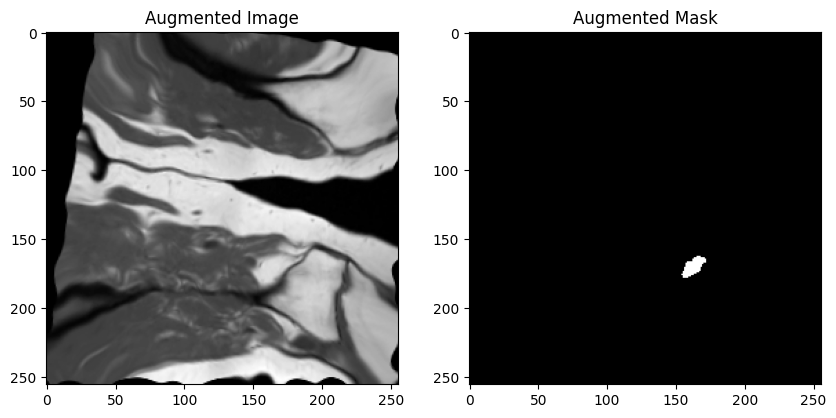

In [ ]:
# This cell is now for the Dataset and Augmentations

import cv2
import albumentations as A
from albumentations.pytorch import ToTensorV2

# Define the augmentation pipeline for the training set
train_transform = A.Compose([
    A.Resize(256, 256),
    A.HorizontalFlip(p=0.5),
    A.VerticalFlip(p=0.5),
    A.GridDistortion(p=0.5),
    A.OpticalDistortion(p=0.5, distort_limit=1, shift_limit=0.5),
    A.Affine(
        rotate=(-15, 15),
        scale=(0.9, 1.1),
        translate_percent=0.05,
        p=0.75
    ),
    A.ElasticTransform(p=0.5, alpha=120, sigma=120 * 0.05, alpha_affine=120 * 0.03),
    A.RandomBrightnessContrast(p=0.5),
    A.Normalize(mean=(0.5,), std=(0.5,)),
    ToTensorV2(),
])

# Define a simpler pipeline for the validation set (no augmentations)
val_transform = A.Compose([
    A.Resize(256, 256),
    A.Normalize(mean=(0.5,), std=(0.5,)),
    ToTensorV2(),
])

class LipomaDataset(Dataset):
    def __init__(self, image_paths, mask_paths, transform=None):
        self.image_paths = image_paths
        self.mask_paths = mask_paths
        self.transform = transform

    def __len__(self):
        return len(self.image_paths)

    def __getitem__(self, idx):
        image_path = self.image_paths[idx]
        mask_path = self.mask_paths[idx]
        
        image = cv2.imread(image_path, cv2.IMREAD_GRAYSCALE)
        mask = cv2.imread(mask_path, cv2.IMREAD_GRAYSCALE)
        
        # Ensure mask is binary (0 or 255) before transformations
        mask = (mask > 0).astype(np.uint8) * 255

        if self.transform:
            transformed = self.transform(image=image, mask=mask)
            image = transformed['image']
            mask = transformed['mask']

        # Ensure mask tensor is binary (0 or 1) and has a channel dimension
        mask = (mask > 0.5).float().unsqueeze(0)

        return image, mask

# Create a placeholder dataset to get all image/mask paths
all_images = sorted(glob.glob(os.path.join(IMAGE_DIR, '*.png')))
all_masks = sorted(glob.glob(os.path.join(MASK_DIR, '*.png')))
# We don't instantiate a full dataset here anymore, it will be done per-fold.


# Demonstrate the augmentation by showing an example
if len(all_images) > 0:
    temp_dataset = LipomaDataset(image_paths=all_images, mask_paths=all_masks, transform=train_transform)
    image, mask = temp_dataset[0]
    
    # Reverse normalization for visualization
    image = (image * 0.5) + 0.5
    
    fig, ax = plt.subplots(1, 2, figsize=(10, 5))
    ax[0].imshow(image.squeeze(), cmap='gray')
    ax[0].set_title('Augmented Image')
    ax[1].imshow(mask.squeeze(), cmap='gray')
    ax[1].set_title('Augmented Mask')
    plt.show()

In [4]:
class ConvBlock(nn.Module):
    def __init__(self, in_channels, out_channels):
        super(ConvBlock, self).__init__()
        self.conv = nn.Sequential(
            nn.Conv2d(in_channels, out_channels, kernel_size=3, padding=1, bias=False),
            nn.BatchNorm2d(out_channels),
            nn.ReLU(inplace=True),
            nn.Conv2d(out_channels, out_channels, kernel_size=3, padding=1, bias=False),
            nn.BatchNorm2d(out_channels),
            nn.ReLU(inplace=True)
        )

    def forward(self, x):
        return self.conv(x)

class AttentionBlock(nn.Module):
    def __init__(self, F_g, F_l, F_int):
        super(AttentionBlock, self).__init__()
        self.W_g = nn.Sequential(
            nn.Conv2d(F_g, F_int, kernel_size=1, stride=1, padding=0, bias=True),
            nn.BatchNorm2d(F_int)
        )
        
        self.W_x = nn.Sequential(
            nn.Conv2d(F_l, F_int, kernel_size=1, stride=1, padding=0, bias=True),
            nn.BatchNorm2d(F_int)
        )

        self.psi = nn.Sequential(
            nn.Conv2d(F_int, 1, kernel_size=1, stride=1, padding=0, bias=True),
            nn.BatchNorm2d(1),
            nn.Sigmoid()
        )
        
        self.relu = nn.ReLU(inplace=True)

    def forward(self, g, x):
        g1 = self.W_g(g)
        x1 = self.W_x(x)
        psi = self.relu(g1 + x1)
        psi = self.psi(psi)
        return x * psi

class AttentionUNet(nn.Module):
    def __init__(self, in_channels=1, out_channels=1, features=[64, 128, 256, 512]):
        super(AttentionUNet, self).__init__()
        self.encoder = nn.ModuleList()
        self.decoder = nn.ModuleList()
        self.pool = nn.MaxPool2d(kernel_size=2, stride=2)

        # Encoder
        for feature in features:
            self.encoder.append(ConvBlock(in_channels, feature))
            in_channels = feature

        # Bottleneck
        self.bottleneck = ConvBlock(features[-1], features[-1] * 2)

        # Decoder
        for feature in reversed(features):
            self.decoder.append(
                nn.ConvTranspose2d(feature * 2, feature, kernel_size=2, stride=2)
            )
            self.decoder.append(AttentionBlock(F_g=feature, F_l=feature, F_int=feature // 2))
            self.decoder.append(ConvBlock(feature * 2, feature))

        self.final_conv = nn.Conv2d(features[0], out_channels, kernel_size=1)

    def forward(self, x):
        skip_connections = []

        # Encode
        for i, down in enumerate(self.encoder):
            x = down(x)
            skip_connections.append(x)
            x = self.pool(x)

        x = self.bottleneck(x)
        skip_connections = skip_connections[::-1]

        # Decode
        # The decoder loop iterates in steps of 3: up-conv, attention, and conv-block.
        for i in range(0, len(self.decoder), 3):
            x = self.decoder[i](x) # Up-convolution
            skip_connection = skip_connections[i//3] # Get skip connection from encoder
            attention = self.decoder[i+1](g=x, x=skip_connection) # Apply attention
            x = torch.cat((attention, x), dim=1) # Concatenate
            x = self.decoder[i+2](x) # Double convolution

        return torch.sigmoid(self.final_conv(x))


# To reduce VRAM usage, you can decrease the number of features, e.g.:
# model = AttentionUNet(features=[64, 128, 256, 512]).to(device)
model = AttentionUNet(features=[64, 128, 256, 512]).to(device)

# Print model summary to check the architecture
print(model)                                                                                                                                 

AttentionUNet(
  (encoder): ModuleList(
    (0): ConvBlock(
      (conv): Sequential(
        (0): Conv2d(1, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
        (1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
        (2): ReLU(inplace=True)
        (3): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
        (4): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
        (5): ReLU(inplace=True)
      )
    )
    (1): ConvBlock(
      (conv): Sequential(
        (0): Conv2d(64, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
        (1): BatchNorm2d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
        (2): ReLU(inplace=True)
        (3): Conv2d(128, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
        (4): BatchNorm2d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
        (5): ReLU(

In [5]:
import torch
import torch.nn as nn
import torch.nn.functional as F

class DiceFocalLoss(nn.Module):
    def __init__(self, weight=None, size_average=True, dice_weight=0.5, focal_weight=0.5):
        super(DiceFocalLoss, self).__init__()
        self.dice_weight = dice_weight
        self.focal_weight = focal_weight

    def forward(self, inputs, targets, smooth=1):
        
        # Comment out if your model contains a Sigmoid as the final layer
        inputs = torch.sigmoid(inputs)       
        
        # Flatten label and prediction tensors
        inputs = inputs.view(-1)
        targets = targets.view(-1)
        
        # --- Dice Loss ---
        intersection = (inputs * targets).sum()                            
        dice_score = (2.*intersection + smooth) / (inputs.sum() + targets.sum() + smooth)  
        dice_loss = 1 - dice_score

        # --- Focal Loss ---
        # BCE = - (y * log(p) + (1-y) * log(1-p))
        # We use standard binary cross entropy as the base
        BCE = F.binary_cross_entropy(inputs, targets, reduction='mean')
        
        # Calculate Pt: if target=1, Pt=p; if target=0, Pt=1-p
        # However, a simpler implementation for Focal Loss using BCE is:
        # FL = alpha * (1-pt)^gamma * log(pt)
        # Here we implement a simplified version without alpha balancing for simplicity,
        # relying on Dice to handle the bulk of imbalance.
        
        BCE_EXP = torch.exp(-BCE)
        focal_loss = 0.8 * (1 - BCE_EXP)**2 * BCE  # gamma=2, alpha=0.8 (optional)
        
        # --- Combined ---
        final_loss = (self.dice_weight * dice_loss) + (self.focal_weight * focal_loss)
        
        return final_loss

In [ ]:
# Hyperparameters
LEARNING_RATE = 5e-4
BATCH_SIZE = 8 # Reduced batch size for VRAM
NUM_EPOCHS = 25
NUM_FOLDS = 5

# Loss Function
dice_loss = DiceLoss(to_onehot_y=False, sigmoid=True)
tversky_loss = TverskyLoss(to_onehot_y=False, alpha=0.5, beta=0.5, sigmoid=True)
def combined_loss(pred, target):
    return dice_loss(pred, target) + tversky_loss(pred, target)

# Metric (Dice Coefficient)
# def dice_coefficient(pred, target):
#     smooth = 1e-5
#     pred = (pred > 0.5).float()
#     intersection = (pred * target).sum(dim=(2, 3))
#     union = pred.sum(dim=(2, 3)) + target.sum(dim=(2, 3))
#     dice = (2. * intersection + smooth) / (union + smooth)
#     return dice.mean()

def dice_coefficient(pred, target):
    return dice_loss(pred, target)

# Training and Validation Functions
def train_epoch(loader, model, optimizer, loss_fn):
    model.train()
    total_loss = 0
    total_dice = 0
    for images, masks in loader:
        images, masks = images.to(device), masks.to(device)
        optimizer.zero_grad()
        preds = model(images)
        loss = loss_fn(preds, masks)
        loss.backward()
        optimizer.step()
        total_loss += loss.item()
        total_dice += dice_coefficient(preds, masks).item()
    return total_loss / len(loader), total_dice / len(loader)

def validate_epoch(loader, model, loss_fn):
    model.eval()
    total_loss = 0
    total_dice = 0
    with torch.no_grad():
        for images, masks in loader:
            images, masks = images.to(device), masks.to(device)
            preds = model(images)
            loss = loss_fn(preds, masks)
            total_loss += loss.item()
            total_dice += dice_coefficient(preds, masks).item()
    return total_loss / len(loader), total_dice / len(loader)

# 5-Fold Cross-Validation (Patient-Level)
patient_ids = sorted(list(set([os.path.basename(p).split('_slice_')[0] for p in all_images])))
kf = KFold(n_splits=NUM_FOLDS, shuffle=True, random_state=42)
fold_results = []

criterion = DiceFocalLoss(dice_weight=0.5, focal_weight=0.5)

for fold, (train_patient_indices, val_patient_indices) in enumerate(kf.split(patient_ids)):
    print(f'--- Fold {fold+1}/{NUM_FOLDS} ---')
    
    train_patients = [patient_ids[i] for i in train_patient_indices]
    val_patients = [patient_ids[i] for i in val_patient_indices]

    # Get image and mask paths for the current fold
    train_images = [img for img in all_images if os.path.basename(img).split('_slice_')[0] in train_patients]
    train_masks = [mask for mask in all_masks if os.path.basename(mask).split('_slice_')[0] in train_patients]
    
    val_images = [img for img in all_images if os.path.basename(img).split('_slice_')[0] in val_patients]
    val_masks = [mask for mask in all_masks if os.path.basename(mask).split('_slice_')[0] in val_patients]

    # Create datasets for the current fold
    train_dataset = LipomaDataset(image_paths=train_images, mask_paths=train_masks, transform=train_transform)
    val_dataset = LipomaDataset(image_paths=val_images, mask_paths=val_masks, transform=val_transform)
    
    # Create dataloaders
    train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True)
    val_loader = DataLoader(val_dataset, batch_size=BATCH_SIZE, shuffle=False)
    
    # Initialize model, optimizer and scheduler
    model = AttentionUNet(features=[96, 192, 384, 768]).to(device) # Bigger model
    optimizer = torch.optim.AdamW(model.parameters(), lr=LEARNING_RATE)
    scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(optimizer, 'min', patience=3, factor=0.1)

    history = {'train_loss': [], 'val_loss': [], 'train_dice': [], 'val_dice': []}
    best_val_dice = -1.0

    for epoch in range(NUM_EPOCHS):
        train_loss, train_dice = train_epoch(train_loader, model, optimizer, criterion)
        val_loss, val_dice = validate_epoch(val_loader, model, criterion)
        
        scheduler.step(val_loss)

        print(f'Epoch {epoch+1}/{NUM_EPOCHS} -> Train Loss: {train_loss:.4f}, Val Loss: {val_loss:.4f}, Train Dice: {train_dice:.4f}, Val Dice: {val_dice:.4f}')
        
        history['train_loss'].append(train_loss)
        history['val_loss'].append(val_loss)
        history['train_dice'].append(train_dice)
        history['val_dice'].append(val_dice)
        
        if val_dice > best_val_dice:
            best_val_dice = val_dice
            torch.save(model.state_dict(), f'best_model_fold_{fold+1}.pth')

    fold_results.append({'history': history, 'model_path': f'best_model_fold_{fold+1}.pth', 'val_patients': val_patients})

print('Finished 5-Fold Cross-Validation.')

--- Fold 1/5 ---
Epoch 1/25 -> Train Loss: 0.5796, Val Loss: 0.5572, Train Dice: 0.9610, Val Dice: 0.9442
Epoch 2/25 -> Train Loss: 0.5635, Val Loss: 0.5504, Train Dice: 0.9615, Val Dice: 0.9445
Epoch 3/25 -> Train Loss: 0.5569, Val Loss: 0.5455, Train Dice: 0.9610, Val Dice: 0.9430
Epoch 4/25 -> Train Loss: 0.5545, Val Loss: 0.5438, Train Dice: 0.9617, Val Dice: 0.9435
Epoch 5/25 -> Train Loss: 0.5537, Val Loss: 0.5456, Train Dice: 0.9617, Val Dice: 0.9460
Epoch 6/25 -> Train Loss: 0.5527, Val Loss: 0.5433, Train Dice: 0.9632, Val Dice: 0.9459
Epoch 7/25 -> Train Loss: 0.5524, Val Loss: 0.5430, Train Dice: 0.9640, Val Dice: 0.9461
Epoch 8/25 -> Train Loss: 0.5516, Val Loss: 0.5428, Train Dice: 0.9633, Val Dice: 0.9460
Epoch 9/25 -> Train Loss: 0.5514, Val Loss: 0.5425, Train Dice: 0.9635, Val Dice: 0.9461
Epoch 10/25 -> Train Loss: 0.5512, Val Loss: 0.5425, Train Dice: 0.9634, Val Dice: 0.9461
Epoch 11/25 -> Train Loss: 0.5509, Val Loss: 0.5424, Train Dice: 0.9633, Val Dice: 0.9461
Ep

In [ ]:
# Plotting Training History
for i, result in enumerate(fold_results):
    plt.figure(figsize=(12, 5))
    plt.subplot(1, 2, 1)
    plt.plot(result['history']['train_loss'], label='Train Loss')
    plt.plot(result['history']['val_loss'], label='Val Loss')
    plt.title(f'Fold {i+1} - Loss')
    plt.legend()

    plt.subplot(1, 2, 2)
    plt.plot(result['history']['train_dice'], label='Train Dice')
    plt.plot(result['history']['val_dice'], label='Val Dice')
    plt.title(f'Fold {i+1} - Dice Coefficient')
    plt.legend()
    plt.show()

# Displaying Qualitative Results from the best model of a fold
best_fold_idx = np.argmax([max(r['history']['val_dice']) for r in fold_results])
print(f"Showing results from Fold {best_fold_idx+1}, which had the best validation Dice score.")

# Load the best model from the best fold
best_model_path = fold_results[best_fold_idx]['model_path']
model = AttentionUNet(features=[64, 128, 256, 512]).to(device)
model.load_state_dict(torch.load(best_model_path))
model.eval()

# Get the validation data from that fold
val_patients = fold_results[best_fold_idx]['val_patients']
val_images = [img for img in all_images if os.path.basename(img).split('_slice_')[0] in val_patients]
val_masks = [mask for mask in all_masks if os.path.basename(mask).split('_slice_')[0] in val_patients]
val_dataset = LipomaDataset(image_paths=val_images, mask_paths=val_masks, transform=val_transform)
val_loader = DataLoader(val_dataset, batch_size=3, shuffle=True)


with torch.no_grad():
    images, masks = next(iter(val_loader))
    images, masks = images.to(device), masks.to(device)
    preds = model(images)

    plt.figure(figsize=(15, 15))
    for i in range(3):
        plt.subplot(3, 3, i*3 + 1)
        plt.imshow(images[i].cpu().squeeze(), cmap='gray')
        plt.title(f'Image')
        plt.axis('off')

        plt.subplot(3, 3, i*3 + 2)
        plt.imshow(masks[i].cpu().squeeze(), cmap='gray')
        plt.title(f'Ground Truth')
        plt.axis('off')

        plt.subplot(3, 3, i*3 + 3)
        plt.imshow(preds[i].cpu().squeeze() > 0.5, cmap='gray')
        plt.title(f'Prediction')
        plt.axis('off')
    plt.tight_layout()
    plt.show()

# Cross-Validation Results Summary
print('--- Cross-Validation Results ---')
final_val_dices = [max(r['history']['val_dice']) for r in fold_results]
final_val_losses = [min(r['history']['val_loss']) for r in fold_results]

for i in range(NUM_FOLDS):
    print(f'Fold {i+1}: Best Val Loss = {final_val_losses[i]:.4f}, Best Val Dice = {final_val_dices[i]:.4f}')

print(f'Average Best Val Loss: {np.mean(final_val_losses):.4f} +/- {np.std(final_val_losses):.4f}')
print(f'Average Best Val Dice: {np.mean(final_val_dices):.4f} +/- {np.std(final_val_dices):.4f}')